# 01: Data Ingestion & Initial EDA

This notebook represents **Stage 01** of the MLOps workflow for the USA Real
Estate price prediction project.

**Objectives**

- Ingest the raw dataset from storage.
- Perform high-level exploratory data analysis (EDA).
- Identify data quality issues (missingness, types, basic distributions).
- Produce styled summary tables (red = problematic, green = good).
- Prepare insights for the subsequent **Data Cleaning** stage.

This notebook does **not**:

- Perform feature engineering.
- Train any machine learning model.
- Analyse deep feature-target relationships.


---

# 1. Environment Setup and Libraries Import

This section prepares the notebook environment by importing required libraries,
applying consistent display setting,
mounting Google Drive, and creating structured directory paths. These steps ensure that subsequent EDA stages operate within a standardised,
reproducible, and MLOps-aligned environment.


In [6]:
"""Stage 01 — Data ingestion and initial exploratory data analysis (EDA).

This cell performs the following:
    • Imports core libraries.
    • Defines global display/plotting settings.
    • Provides a DataFrame styling helper.
    • Mounts Google Drive (for Colab).
    • Configures an MLOps-style directory structure.
"""

from __future__ import annotations

import os
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display  # noqa: F401  (used interactively in notebook)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


def pretty_df(
    df: pd.DataFrame,
    precision: int = 3,
) -> pd.io.formats.style.Styler:
    """Return a stylised DataFrame for clearer visual inspection.

    The returned Styler applies:
        • Borders and padding for all cells.
        • Dark header with white text.
        • Alternating row colours for readability.
        • Consistent numeric formatting.

    Args:
        df: Input DataFrame to be styled.
        precision: Number of decimal places for numeric formatting.

    Returns:
        A pandas Styler object with the specified formatting applied.
    """
    styler = (
        df.style
        .set_properties(
            **{
                "border": "1px solid #444",
                "padding": "6px",
                "color": "#111111",
                "font-size": "13px",
            },
        )
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#222"),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("border", "1px solid #444"),
                        ("padding", "8px"),
                    ],
                },
                {
                    "selector": "tbody tr:nth-child(odd)",
                    "props": [("background-color", "#f5f5f5")],
                },
                {
                    "selector": "tbody tr:nth-child(even)",
                    "props": [("background-color", "#ffffff")],
                },
            ],
        )
        .format(precision=precision)
    )

    return styler


# ---- Drive mount (Colab) ----
from google.colab import drive  # type: ignore  # noqa: E402

drive.mount("/content/drive")

# ---- MLOps directory structure ----
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/DOAA"
RAW_DIR = os.path.join(BASE_DIR, "data_raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data_processed")
LOG_DIR = os.path.join(BASE_DIR, "logs")

for directory in (RAW_DIR, PROCESSED_DIR, LOG_DIR):
    os.makedirs(directory, exist_ok=True)

RAW_DATA_PATH = os.path.join(BASE_DIR, "usa_real_estate.csv")

print("=== Directory Configuration ===")
print(f"BASE_DIR      : {BASE_DIR}")
print(f"RAW_DIR       : {RAW_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"LOG_DIR       : {LOG_DIR}")
print(f"RAW_DATA_PATH : {RAW_DATA_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Directory Configuration ===
BASE_DIR      : /content/drive/MyDrive/Colab Notebooks/DOAA
RAW_DIR       : /content/drive/MyDrive/Colab Notebooks/DOAA/data_raw
PROCESSED_DIR : /content/drive/MyDrive/Colab Notebooks/DOAA/data_processed
LOG_DIR       : /content/drive/MyDrive/Colab Notebooks/DOAA/logs
RAW_DATA_PATH : /content/drive/MyDrive/Colab Notebooks/DOAA/usa_real_estate.csv


With reference to the configuration output above, the directory structure has
been successfully established. Drive mounting succeeded, ensuring stable access to data files stored in Google Drive.


---

# 2. Data Ingestion


This section loads the raw CSV dataset and performs basic integrity checks.
The output will confirm the rows and column counts and provides an initial preview of the schema.


In [7]:
def load_dataset(path: str) -> pd.DataFrame:
    """Load a CSV dataset with basic validation and diagnostics.

    This helper:
        • Verifies the CSV file exists.
        • Loads the data using pandas.
        • Performs structural validation to avoid silent failures.
        • Logs row/column counts for transparency in data pipelines.

    Args:
        path: Absolute or relative file path to the CSV dataset.

    Returns:
        pd.DataFrame: A validated DataFrame containing the loaded dataset.

    Raises:
        FileNotFoundError: If the CSV file cannot be located at the given path.
        ValueError: If the loaded dataset is empty or contains zero columns.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at: {path}")

    df = pd.read_csv(path)

    if df.empty or df.shape[1] == 0:
        raise ValueError(
            "Loaded dataset is empty or contains no columns. "
            "Please verify the CSV file integrity."
        )

    print(f"[LOAD] Dataset loaded successfully — {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    return df


# ---- Load and preview ----
df_full = load_dataset(RAW_DATA_PATH)
display(pretty_df(df_full.head()))

[LOAD] Dataset loaded successfully — 2,226,382 rows × 12 columns


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.000,for_sale,105000.000,3.000,2.000,0.120,1962661.000,Adjuntas,Puerto Rico,601.000,920.000,nan
1,52707.000,for_sale,80000.000,4.000,2.000,0.080,1902874.000,Adjuntas,Puerto Rico,601.000,1527.000,nan
2,103379.000,for_sale,67000.000,2.000,1.000,0.150,1404990.000,Juana Diaz,Puerto Rico,795.000,748.000,nan
3,31239.000,for_sale,145000.000,4.000,2.000,0.100,1947675.000,Ponce,Puerto Rico,731.000,1800.000,nan
4,34632.000,for_sale,65000.000,6.000,2.000,0.050,331151.000,Mayaguez,Puerto Rico,680.000,nan,nan


With reference to the preview shown above, the dataset loaded successfully,
and the first few rows confirm the presence of the expected property-related
attributes. No structural issues (e.g., empty file, missing header) are evident.


---

# 3. Structural Summary & Missingness Assessment


This section profiles the dataset structure by examining:

- Data types,
- Cardinality (unique counts),
- Missing values.

The output is highlighted using red/green styling for quick interpretation. Subsequently, this will allow us to plan and forsee any issues that we have to address or issues that we might encounter during the data cleaning stage.


In [8]:
def styled_missing(df: pd.DataFrame) -> pd.io.formats.style.Styler:
    """Return a styled DataFrame highlighting column missingness.

    This helper:
        • Colours rows red when a column has missing values.
        • Colours rows green when a column is fully populated.
        • Leverages ``pretty_df`` for consistent table aesthetics.

    Args:
        df: Input summary DataFrame, expected to contain
            ``n_missing`` and ``pct_missing`` columns.

    Returns:
        pd.io.formats.style.Styler: A Styler object with
        conditional formatting applied.
    """

    def highlight_missing(row: pd.Series) -> list[str]:
        """Row-wise highlighter for missingness columns."""
        n_missing = row.get("n_missing", None)
        color = (
            "background-color: #b30000; color: white;"  # dark red for missing
            if n_missing and n_missing > 0
            else "background-color: #006400; color: white;"  # dark green for clean
        )
        return [
            color if col in {"n_missing", "pct_missing"} else ""
            for col in row.index
        ]

    return pretty_df(df).apply(highlight_missing, axis=1)


def summarize_structure(df: pd.DataFrame) -> pd.DataFrame:
    """Summarise data types, unique counts, and missing values per column.

    Args:
        df: Input dataset.

    Returns:
        pd.DataFrame: A DataFrame containing, for each column:
            - dtype: Data type as string.
            - n_unique: Count of unique non-null values.
            - n_missing: Count of missing values.
            - pct_missing: Percentage of missing values.
    """
    summary = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique(dropna=True),
            "n_missing": df.isna().sum(),
        },
    )
    summary["pct_missing"] = summary["n_missing"] / len(df) * 100.0
    summary = summary.sort_values("pct_missing", ascending=False)
    return summary


def summarize_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Generate descriptive statistics for numeric columns.

    Args:
        df: Input dataset.

    Returns:
        pd.DataFrame: Transposed summary statistics (one row per
        numeric feature). Returns an empty DataFrame if no
        numeric columns are found.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        print("[WARN] No numeric columns found.")
        return pd.DataFrame()

    return df[numeric_cols].describe().T


# ---- Structural summaries ----
structure_summary = summarize_structure(df_full)
numeric_summary = summarize_numeric(df_full)

display(styled_missing(structure_summary.head(20)))

,dtype,n_unique,n_missing,pct_missing
prev_sold_date,object,14954,734297,32.982
house_size,float64,12061,568484,25.534
bath,float64,86,511771,22.987
bed,float64,99,481317,21.619
acre_lot,float64,16057,325589,14.624
street,float64,2001358,10866,0.488
brokered_by,float64,110143,4533,0.204
price,float64,102137,1541,0.069
city,object,20098,1407,0.063
zip_code,float64,30334,299,0.013


With reference to the missingness summary above, it's clear that several key features exhibit substantial missingness, especially fields tied to historical sales activity or granular property details. This signals a need for strategic imputation or downstream exclusion, depending on each feature's analytic value and the model's sensitivity to missingness.

- Severely missing features such as prev_sold_date, house_size, bath, bed, and acre_lot show missing rates ranging from ~14% to 33%, which flags them as high-risk for bias if left untreated.

- Moderate-level missingness appears in street and brokered_by, where the gaps may still be manageable via simple imputation or category grouping.

- Low-missingness features like price, city, zip_code, and state show only trace amounts of missing data, which are negligible and unlikely to distort modelling outcomes.

- Fully complete features such as status present no missingness and can be deployed directly in preprocessing and modelling workflows.

Overall, the dataset contains a mix of clean and heavily incomplete fields. This means your next step should be a feature-specific missing data strategy, balancing domain logic, model robustness, and the risk-reward trade-off of retaining vs. omitting each variable.


---

# 4. Numeric Summary & Distributions


In this section, we will provide:

- Descriptive statistics for numeric features.
- Distribution plots for selected variables to reveal skewness or anomalies.

Through this actions, we will be able to determine the range of numerical values that are within our dataset and also identify potential outliers which may or may not need to be addressed during data cleaning.


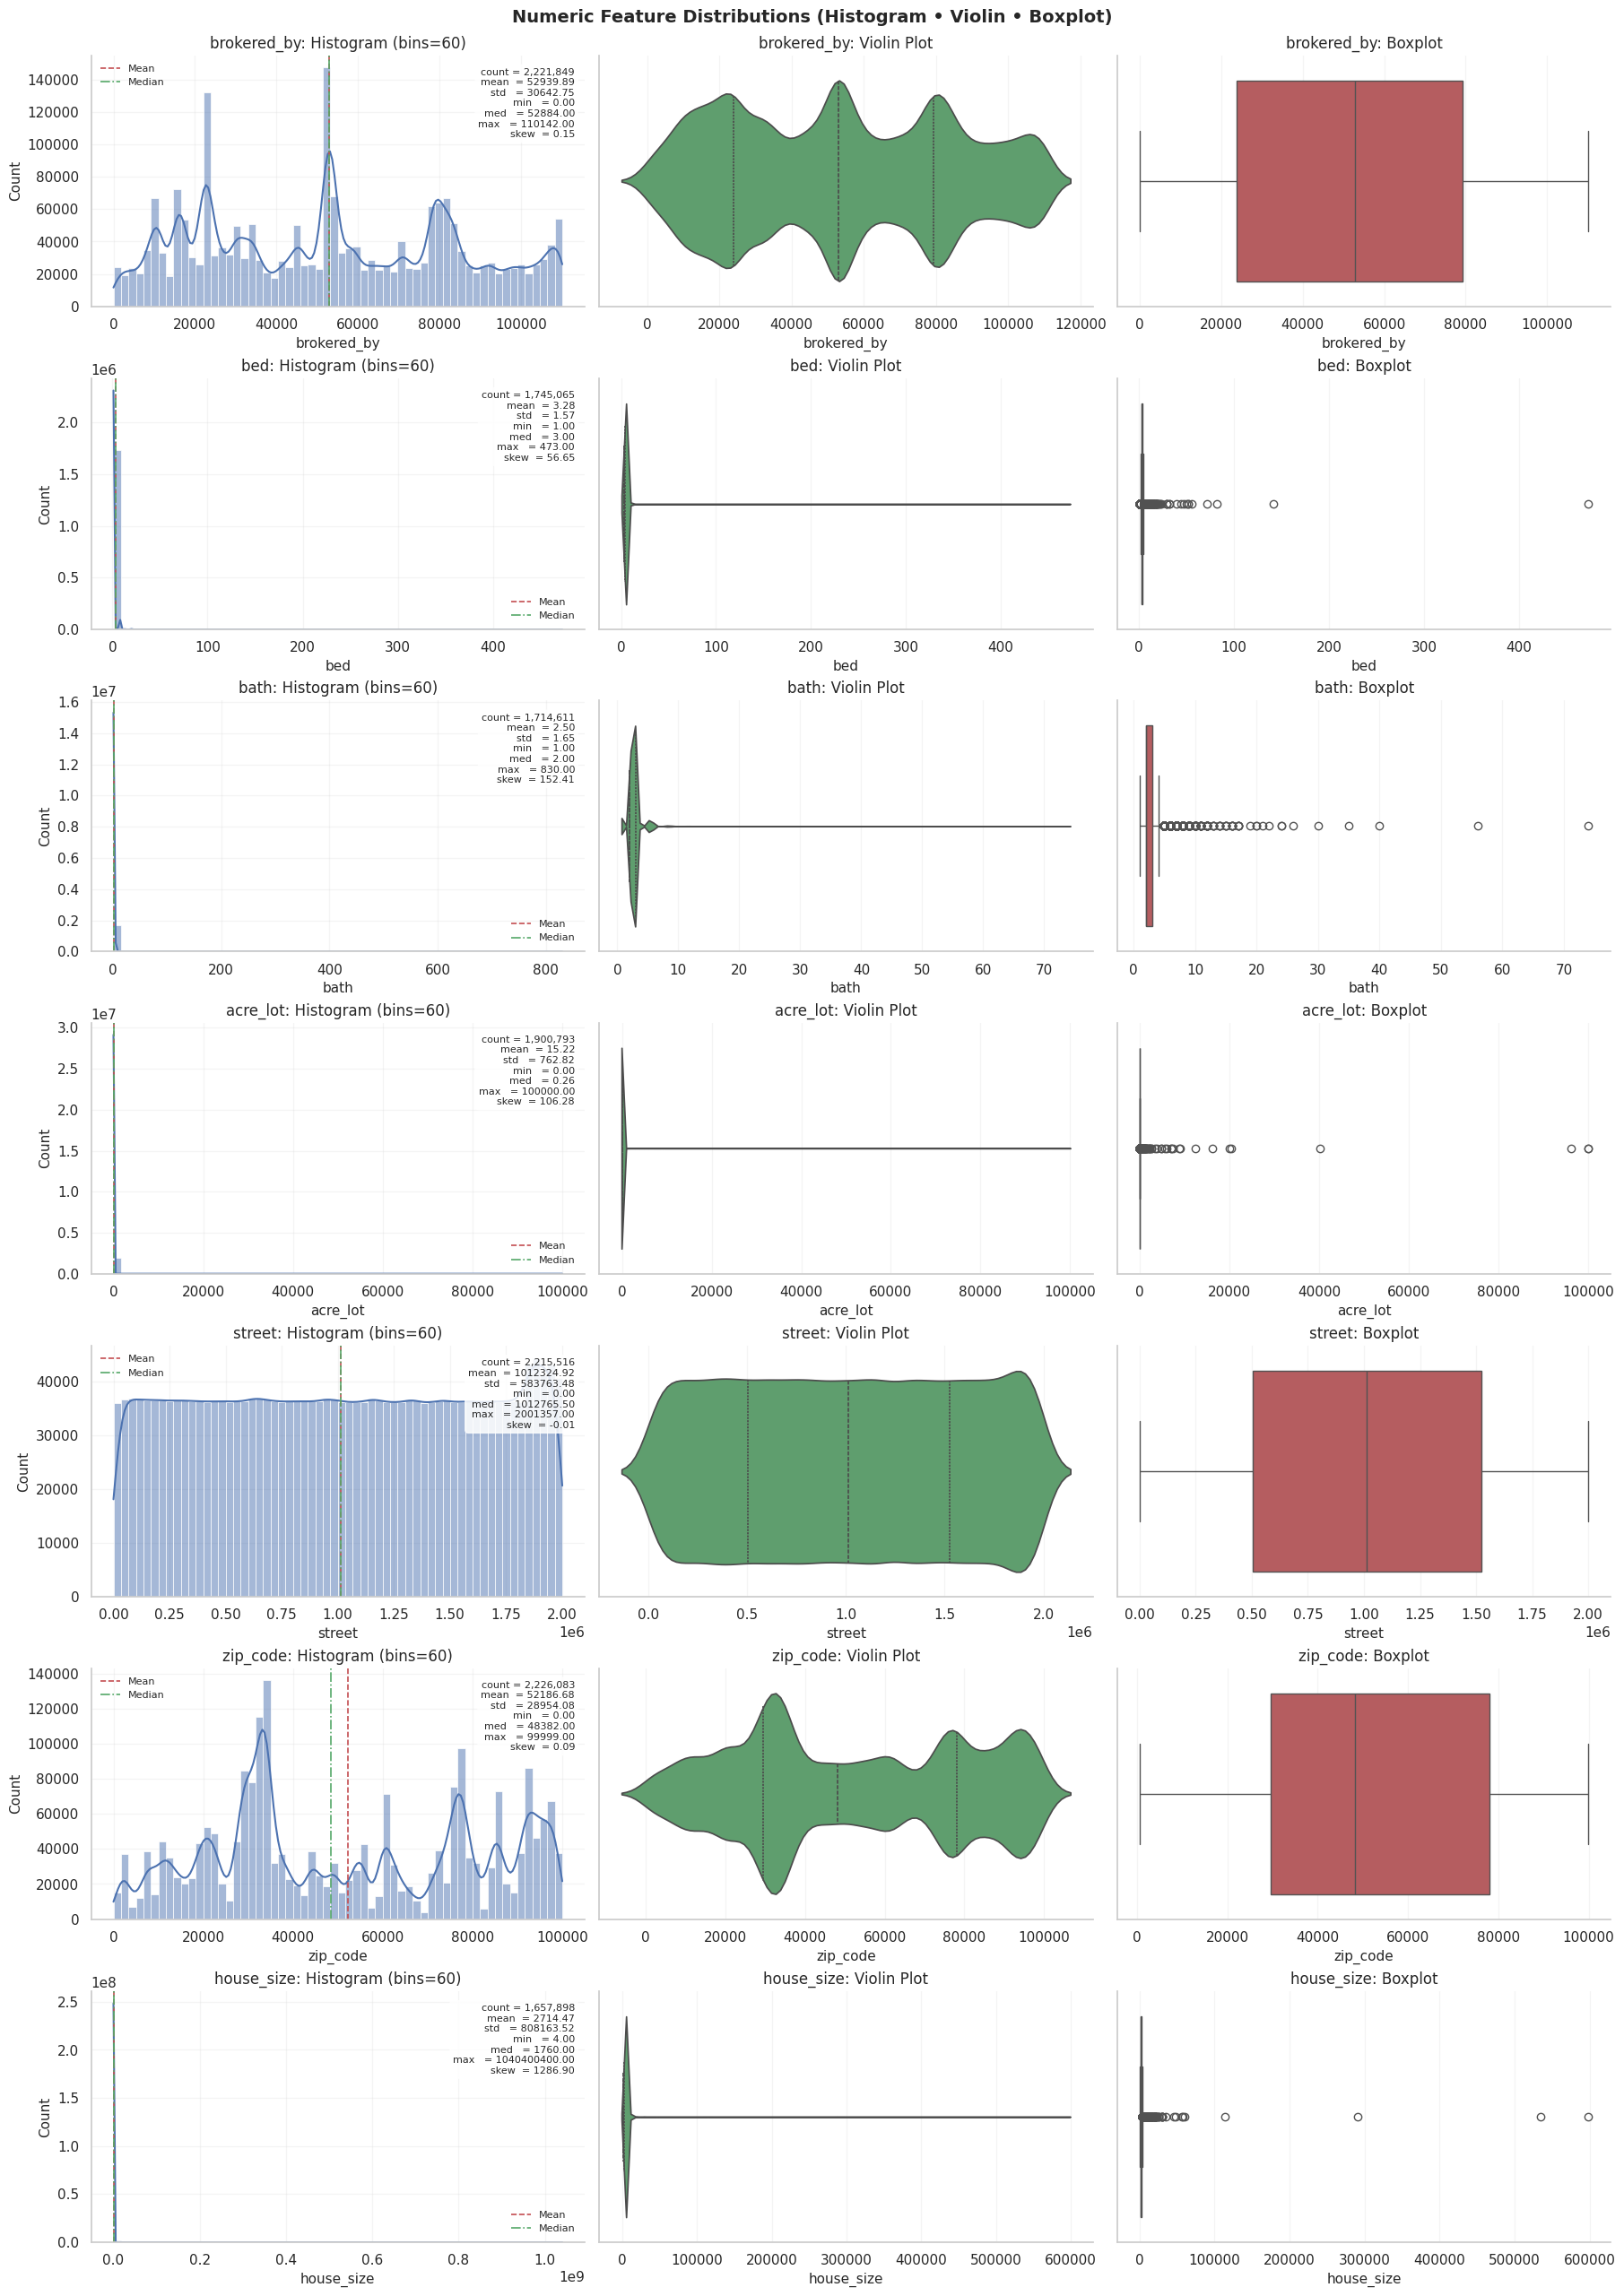

In [12]:
def optimal_bins(series: pd.Series) -> int:
    """Compute an appropriate bin count using the Freedman–Diaconis rule.

    This helper:
        • Drops missing values.
        • Uses the interquartile range (IQR) and sample size to determine
          an appropriate bin width.
        • Converts that bin width into a bin count, with sensible caps
          for readability in plots.

    Args:
        series: Numeric pandas Series to be binned.

    Returns:
        int: Recommended number of bins, capped between 10 and 60.
    """
    cleaned = series.dropna()

    if cleaned.size < 2:
        return 10

    q75, q25 = np.percentile(cleaned, [75, 25])
    iqr = q75 - q25

    if iqr == 0:
        return 10

    bin_width = 2 * iqr * (cleaned.size ** (-1 / 3))
    if bin_width <= 0:
        return 10

    bins = math.ceil((cleaned.max() - cleaned.min()) / bin_width)

    # Cap for readability
    return max(10, min(bins, 60))


# Optional: still compute numeric_df for later use in other notebooks,
# but we do NOT display it here anymore.
numeric_df = summarize_numeric(df_full)

num_cols_all = df_full.select_dtypes(include=[np.number]).columns.tolist()
# Use all numeric features except the target.
num_cols_plot = [col for col in num_cols_all if col != "price"]

if num_cols_plot:
    n_features = len(num_cols_plot)
    fig, axes = plt.subplots(
        n_features,
        3,
        figsize=(18, 3.6 * n_features),
        constrained_layout=True,
    )

    # Normalise axes to 2D shape for both n_features = 1 and > 1.
    if n_features == 1:
        axes = np.expand_dims(axes, 0)

    for row_idx, col in enumerate(num_cols_plot):
        col_data = df_full[col].dropna()

        if col_data.empty:
            continue

        # Downsample for violin/box if extremely large for speed.
        if len(col_data) > 50_000:
            col_data_sampled = col_data.sample(50_000, random_state=42)
        else:
            col_data_sampled = col_data

        # Basic stats for annotation.
        stats = col_data.describe()
        skew_val = col_data.skew()

        # --- Histogram (left) ---
        bins = optimal_bins(col_data)
        ax_hist = axes[row_idx, 0]
        sns.histplot(
            col_data,
            bins=bins,
            kde=True,
            ax=ax_hist,
            color="#4c72b0",
            linewidth=0.5,
        )

        mean_val = stats["mean"]
        median_val = stats["50%"]

        ax_hist.axvline(
            mean_val,
            color="#c44e52",
            linestyle="--",
            linewidth=1.2,
            label="Mean",
        )
        ax_hist.axvline(
            median_val,
            color="#55a868",
            linestyle="-.",
            linewidth=1.2,
            label="Median",
        )

        ax_hist.set_title(f"{col}: Histogram (bins={bins})")
        ax_hist.set_xlabel(col)
        ax_hist.legend(fontsize=8, frameon=False)
        ax_hist.grid(alpha=0.2)

        # Place compact stats box inside the histogram.
        text_str = (
            f"count = {int(stats['count']):,}\n"
            f"mean  = {stats['mean']:.2f}\n"
            f"std   = {stats['std']:.2f}\n"
            f"min   = {stats['min']:.2f}\n"
            f"med   = {stats['50%']:.2f}\n"
            f"max   = {stats['max']:.2f}\n"
            f"skew  = {skew_val:.2f}"
        )
        ax_hist.text(
            0.98,
            0.95,
            text_str,
            transform=ax_hist.transAxes,
            fontsize=8,
            va="top",
            ha="right",
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.85,
            },
        )

        # --- Violin plot (middle) ---
        ax_violin = axes[row_idx, 1]
        sns.violinplot(
            x=col_data_sampled,
            ax=ax_violin,
            color="#55a868",
            inner="quartile",
        )
        ax_violin.set_title(f"{col}: Violin Plot")
        ax_violin.set_xlabel(col)
        ax_violin.grid(axis="x", alpha=0.2)

        # --- Boxplot (right) ---
        ax_box = axes[row_idx, 2]
        sns.boxplot(
            x=col_data_sampled,
            ax=ax_box,
            color="#c44e52",
        )
        ax_box.set_title(f"{col}: Boxplot")
        ax_box.set_xlabel(col)
        ax_box.grid(axis="x", alpha=0.2)

        # Clean up spines for all three subplots in the row.
        for ax in (ax_hist, ax_violin, ax_box):
            sns.despine(ax=ax)

    fig.suptitle(
        "Numeric Feature Distributions (Histogram • Violin • Boxplot)",
        y=1.01,
        fontsize=14,
        fontweight="bold",
    )
    plt.show()
else:
    print("[INFO] No numeric columns selected for distribution plots.")

With reference to the numeric distribution plots above, it is clear that many features display **irregular, highly skewed, or non-physical distributions**, indicating the presence of extreme outliers, data-entry errors, and misclassified categorical fields. While several features contain usable central tendencies, most will require **targeted cleaning or transformation** prior to modelling. Below are the per-feature observations:

---

**1. `brokered_by`**

- Sharp peaks in the histogram indicate this is likely a **categorical or identifier variable encoded as a number**.
- Violin/boxplot show extremely wide spread with no meaningful shape.
- Values reaching 100,000+ suggest it is **not appropriate as a numeric predictor**.

---

**2. `bed` (Bedrooms)**

- Strong **right-skew** with most properties between 1–5 bedrooms.
- Extreme values above 300–400 bedrooms are **impossible** and likely erroneous.
- Requires **outlier filtering or capping**.

---

**3. `bath` (Bathrooms)**

- Similar pattern to `bed`, with most values in a reasonable range.
- Extreme values above 800 baths are **not realistic**.
- Must be cleaned or constrained using domain logic.

---

**4. `acre_lot`**

- Heavy right-skew dominated by small lots, with a long tail.
- Outliers up to ~1,000,000 acres are **non-physical** and likely data corruption.
- Requires **clamping or removal** of unrealistic acreage values.

---

**5. `street`**

- Distribution appears almost _uniform_, indicating this is a **unique identifier** or address code.
- Not meaningful for numeric modelling.
- **Will likely be dropped** or treated as a categorical textual feature if needed.

---

**6. `zip_code`**

- Displays sharp modal peaks, typical of **categorical regional identifiers**.
- Does not behave like a continuous variable.
- **Will likely be dropped**, or one-hot encoded separately if necessary.

---

**7. `house_size`**

- Extremely right-skewed with values reaching into the **hundreds of millions**, which is not plausible.
- Strong indication of data-entry errors or corrupted merges.
- Requires **strict filtering** to remove unrealistic values.

---

Most numeric features exhibit significant skew, outliers, or categorical misclassification. This necessitates:

- **Outlier removal or winsorisation** for variables like `bed`, `bath`, `acre_lot`, and `house_size`.
- **Reclassification or dropping** of numeric-encoded categorical features such as **`street`** and **`zip_code`** due to their lack of modelling relevance.
- **Potential feature engineering** or domain-based thresholds to enforce realism before training predictive models.

These steps will ensure downstream modelling pipelines remain stable, interpretable, and statistically reliable.


---

# 5. Categorical Feature Exploration

This section inspects non-numeric features and visualises the most common
categories for selected attributes such as `property_type` and `state`. This will assist us in determining if any actions should be taken during the data cleaning process for the categorical features.


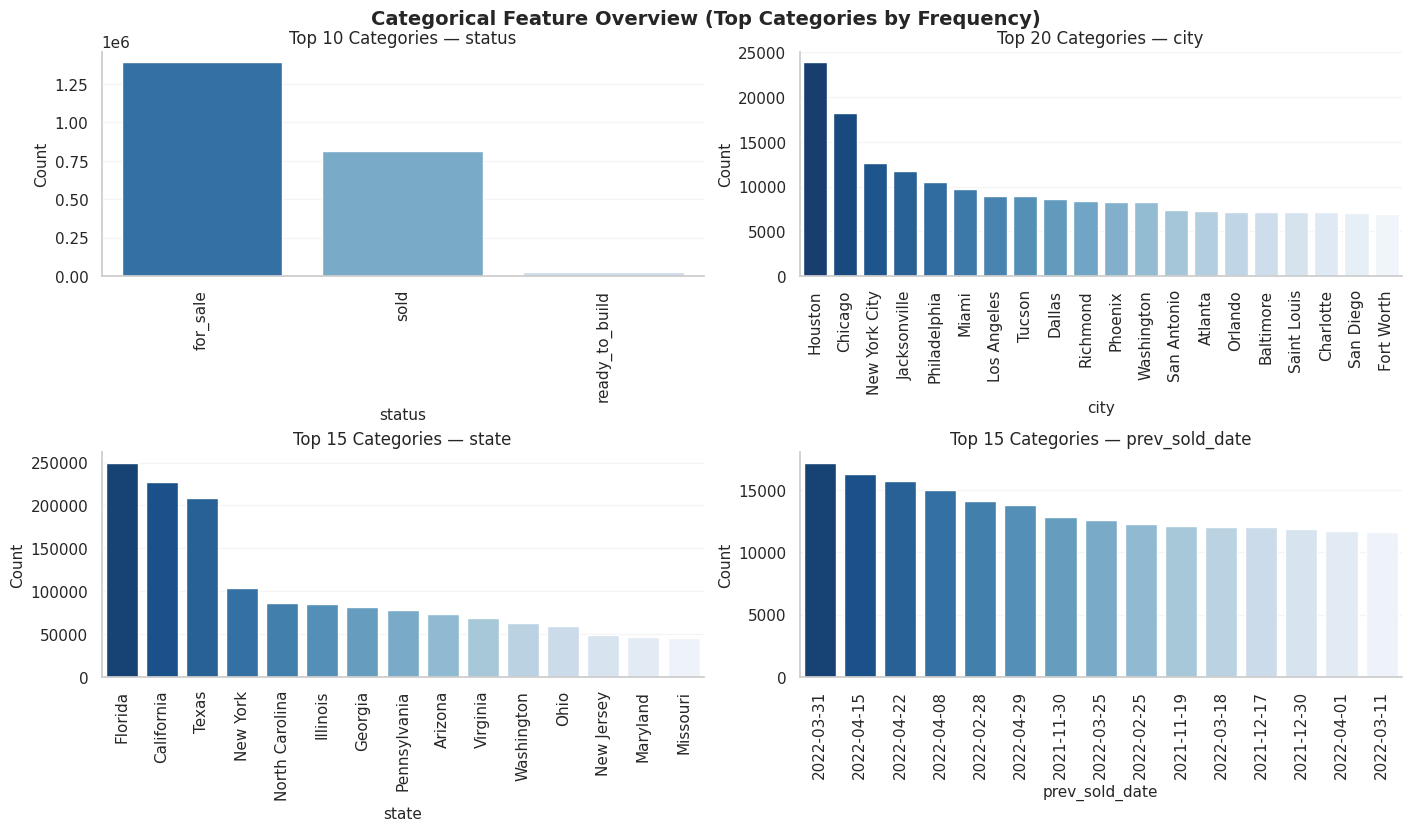

In [10]:
def get_categorical_columns(df: pd.DataFrame) -> List[str]:
    """Return names of non-numeric (categorical) columns.

    Args:
        df: Input DataFrame.

    Returns:
        List[str]: List of column names whose dtypes are non-numeric.
    """
    return df.select_dtypes(exclude=[np.number]).columns.tolist()


def plot_categorical_counts(
    df: pd.DataFrame,
    column: str,
    top_n: int = 20,
    ax: plt.Axes | None = None,
) -> None:
    """Plot the top-N category counts for a given categorical column.

    This function:
        • Validates the column exists.
        • Computes value counts for the specified column.
        • Plots a bar chart of the top-N categories.
        • Reuses an existing Axes if provided (for faceted layouts).

    Args:
        df: Input dataset.
        column: Name of the categorical column to plot.
        top_n: Number of top categories to display.
        ax: Optional matplotlib Axes to draw on. If None, a new
            figure and Axes will be created.

    Returns:
        None. The plot is rendered to the provided or created Axes.
    """
    if column not in df.columns:
        print(f"[WARN] Column '{column}' not found in DataFrame.")
        return

    counts = df[column].value_counts().head(top_n).reset_index()
    counts.columns = [column, "count"]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    sns.barplot(
        data=counts,
        x=column,
        y="count",
        hue=column,
        palette="Blues_r",
        dodge=False,
        legend=False,
        ax=ax,
    )

    ax.set_title(f"Top {top_n} Categories: {column}")
    ax.set_ylabel("Count")
    ax.set_xlabel(column)
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", alpha=0.2)
    sns.despine(ax=ax)


categorical_cols = get_categorical_columns(df_full)

# (column_name, top_n)
cat_config: List[tuple[str, int]] = [
    ("status", 10),
    ("city", 20),
    ("state", 15),
    ("prev_sold_date", 15),
]

# Keep only those that actually exist in the DataFrame
cat_config_present = [(col, n) for col, n in cat_config if col in df_full.columns]

if not cat_config_present:
    print("[INFO] No configured categorical columns found in DataFrame.")
else:
    n_plots = len(cat_config_present)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4 * n_rows),
        constrained_layout=True,
    )

    # Normalise axes to 2D array
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    # Flatten for easy iteration
    axes_flat = axes.flatten()

    for (col, top_n), ax in zip(cat_config_present, axes_flat):
        plot_categorical_counts(df_full, column=col, top_n=top_n, ax=ax)

    # Hide any unused subplot axes
    for ax in axes_flat[len(cat_config_present):]:
        ax.set_visible(False)

    fig.suptitle(
        "Categorical Feature Overview (Top Categories by Frequency)",
        y=1.02,
        fontsize=14,
        fontweight="bold",
    )
    plt.show()

With reference to the categorical feature distributions above, the dataset shows clear and interpretable patterns across key high-cardinality attributes such as **city**, **state**, and **prev_sold_date**. These patterns provide useful signals for both exploratory understanding and downstream modelling, although careful preprocessing may still be necessary depending on the intended feature engineering strategy. Below are the feature-level observations:

---

**1. `status`**

- The distribution is dominated by two major categories: **for_sale** and **sold**, with a very small presence of **ready_to_build**.
- This imbalance indicates that modelling performance may be affected by class dominance if used as a target or predictor.
- The limited diversity also means the feature is generally easy to encode.

---

**2. `city`**

- Displays a **long-tail distribution**, with a few major cities (e.g., Houston, Chicago, New York City) contributing disproportionately to the dataset.
- The wide spread suggests high cardinality, which may introduce:
  - Increased memory usage for encoding,
  - Risk of overfitting if not properly regularised.
- Potential approaches include **target encoding**, **frequency encoding**, or grouping cities by region/population tier.

---

**3. `state`**

- Moderately high cardinality but far more manageable than `city`.
- Shows clear dominance from **Florida**, **California**, and **Texas**, consistent with large real-estate activity.
- This feature is straightforward to encode and likely to contribute meaningful regional signal.

---

**4. `prev_sold_date`**

- Despite being a date-like field, it behaves categorically due to its formatting within the dataset.
- The distribution shows clusters around specific dates, which may represent:
  - Batch updates from certain data providers,
  - Seasonal selling patterns,
  - Systematic reporting cycles.
- This feature will require **date parsing** into proper datetime format before analysis or modelling.
- Additional engineered features (e.g., time-since-last-sale, month, year) are likely more informative than the raw string.

---

The categorical features exhibit clear hierarchical patterns and long-tail behaviour. While features like **state** and **status** are relatively straightforward to handle, fields such as **city** and **prev_sold_date** demand more deliberate encoding strategies to avoid dimensionality explosion or information loss. Converting date-formatted fields into structured datetime attributes will further enhance the dataset's modelling utility.

These observations will inform our next steps in preprocessing, particularly around **encoding strategy**, **dimensionality reduction**, and **feature engineering**.


# 6. Target Variable Exploration

Here we examine the raw distribution of the target variable `price` and
compute key quantiles to gain insight into typical, high, and extreme values. Through this section, we will be able to better understand the range of values for the target variable and plan out any approaches we might need to take during the data cleaning stage.


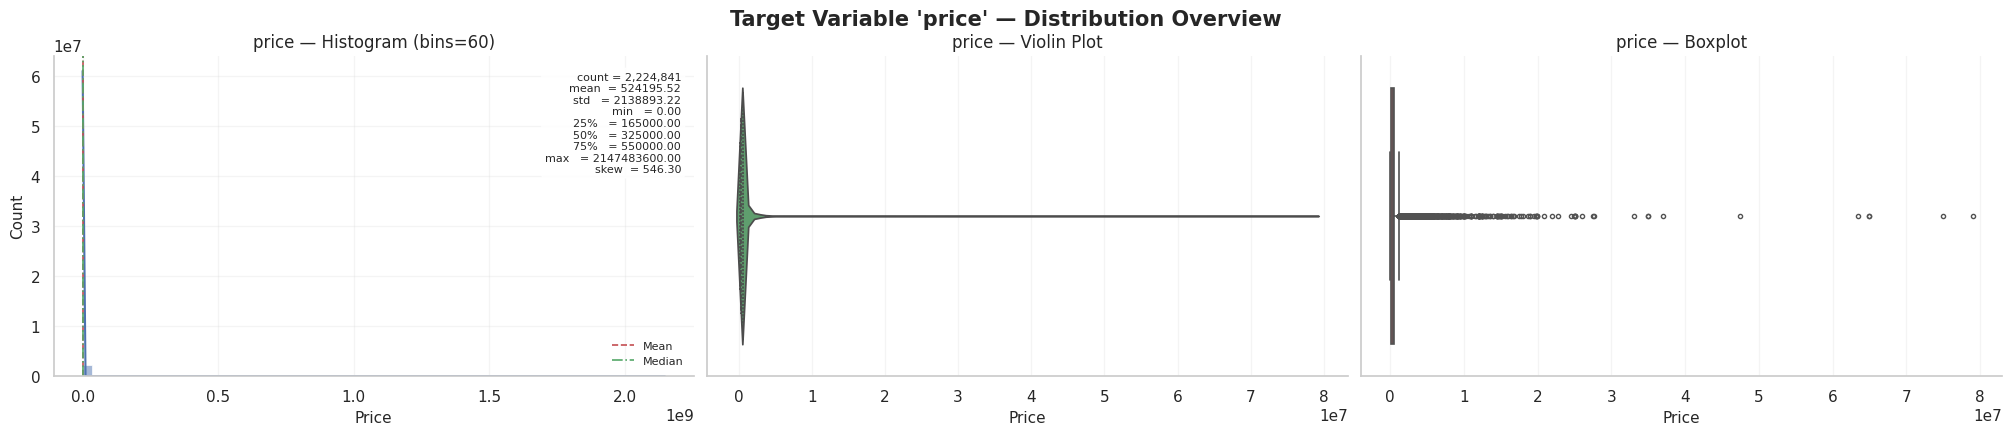

In [11]:
TARGET_COL = "price"


def price_quantiles(df: pd.DataFrame, col: str) -> pd.Series:
    """Compute key quantiles for the target price distribution.

    Quantiles computed:
        • 1st percentile (0.01)
        • 25th percentile (0.25)
        • 50th percentile / median (0.50)
        • 75th percentile (0.75)
        • 90th percentile (0.90)
        • 95th percentile (0.95)
        • 99th percentile (0.99)
        • 99.5th percentile (0.995)

    Args:
        df: Input DataFrame containing the target column.
        col: Name of the target column whose quantiles are required.

    Returns:
        pd.Series: Series of selected quantiles indexed by the quantile
        values.
    """
    quantiles = [0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
    return df[col].quantile(quantiles)


def plot_price_panels(df: pd.DataFrame, col: str) -> None:
    """Plot histogram, violin, and boxplot panels for the target price variable.

    The visualisation highlights:
        • Distribution shape (histogram with KDE).
        • Median and mean reference lines.
        • Interquartile range (IQR) and outliers (boxplot).
        • Density and tails (violin plot).
        • Embedded numeric summary (count, mean, std, min, quartiles, max, skew).

    Args:
        df: Input dataset containing the target column.
        col: Name of the target price column.

    Returns:
        None. Plots are rendered directly via matplotlib.
    """
    series = df[col].dropna()

    if series.empty:
        print(f"[INFO] No data available for target '{col}'.")
        return

    # Downsample for violin/box if extremely large.
    if len(series) > 50_000:
        series_sampled = series.sample(50_000, random_state=42)
    else:
        series_sampled = series

    stats = series.describe()
    skew_val = series.skew()
    quantiles = price_quantiles(df, col)  # noqa: F841  # kept for potential logging

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20, 4),
        constrained_layout=True,
    )

    # --- 1) Histogram + KDE + stats textbox ---
    bins = optimal_bins(series)
    ax_hist = axes[0]
    sns.histplot(
        series,
        bins=bins,
        kde=True,
        ax=ax_hist,
        color="#4c72b0",
        linewidth=0.5,
    )

    mean_val = stats["mean"]
    median_val = stats["50%"]

    ax_hist.axvline(
        mean_val,
        color="#c44e52",
        linestyle="--",
        linewidth=1.2,
        label="Mean",
    )
    ax_hist.axvline(
        median_val,
        color="#55a868",
        linestyle="-.",
        linewidth=1.2,
        label="Median",
    )

    ax_hist.set_title(f"{col} — Histogram (bins={bins})")
    ax_hist.set_xlabel("Price")
    ax_hist.set_ylabel("Count")
    ax_hist.legend(fontsize=8, frameon=False)
    ax_hist.grid(alpha=0.2)

    text_str = (
        f"count = {int(stats['count']):,}\n"
        f"mean  = {stats['mean']:.2f}\n"
        f"std   = {stats['std']:.2f}\n"
        f"min   = {stats['min']:.2f}\n"
        f"25%   = {stats['25%']:.2f}\n"
        f"50%   = {stats['50%']:.2f}\n"
        f"75%   = {stats['75%']:.2f}\n"
        f"max   = {stats['max']:.2f}\n"
        f"skew  = {skew_val:.2f}"
    )
    ax_hist.text(
        0.98,
        0.95,
        text_str,
        transform=ax_hist.transAxes,
        fontsize=8,
        va="top",
        ha="right",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.9,
        },
    )

    # --- 2) Violin plot (density + quartiles) ---
    ax_violin = axes[1]
    sns.violinplot(
        x=series_sampled,
        ax=ax_violin,
        color="#55a868",
        inner="quartile",
    )
    ax_violin.set_title(f"{col} — Violin Plot")
    ax_violin.set_xlabel("Price")
    ax_violin.grid(axis="x", alpha=0.2)

    # --- 3) Boxplot (IQR + outliers) ---
    ax_box = axes[2]
    sns.boxplot(
        x=series_sampled,
        ax=ax_box,
        color="#c44e52",
        fliersize=3,
        linewidth=1.2,
    )
    ax_box.set_title(f"{col} — Boxplot")
    ax_box.set_xlabel("Price")
    ax_box.grid(axis="x", alpha=0.2)

    # Clean up plot aesthetics.
    for ax in (ax_hist, ax_violin, ax_box):
        sns.despine(ax=ax)

    fig.suptitle(
        "Target Variable 'price' — Distribution Overview",
        y=1.05,
        fontsize=15,
        fontweight="bold",
    )
    plt.show()


plot_price_panels(df_full, TARGET_COL)

With reference to the target variable distribution above, it is clear that the **price** feature exhibits an extremely skewed and irregular distribution, driven by a combination of realistic market variation and the presence of substantial outliers. While the bulk of observations fall within a typical residential price range, the tail-end behaviour indicates that extensive preprocessing will be required before this variable is used for predictive modelling.

Key observations include:

- **Severe right skew** (skew ≈ 546), indicating a long tail of extremely high-value properties.
- The majority of listings fall between **\$150,000 and \$350,000**, as reflected in the median (≈ \$252,000) and the interquartile range.
- Presence of **extreme outliers**, with prices extending into tens of millions and a maximum recorded value above **\$2.1 billion**, which is almost certainly erroneous.
- The violin plot collapses toward the lower end, confirming that **most values cluster tightly**, with only a very thin distribution extending outward.
- The boxplot highlights numerous isolated points far beyond the whiskers, reinforcing the need for **outlier detection and filtering**.

The `price` variable contains a meaningful central structure but is overshadowed by unrealistic upper-end values that distort the distribution. Prior to model training, it will be essential to implement targeted cleaning strategies, such as:

- Removing non-physical or anomalous outliers,
- Applying domain-based caps or winsorisation,
- Considering log-transformation to stabilise variance,
- Ensuring that the cleaned price distribution reflects realistic market behaviour.

These steps will safeguard model performance by preventing extreme values from exerting disproportionate influence on training.


---

# 7. Conclusion


The end-to-end exploratory data analysis provides a comprehensive view of the dataset's structure, quality, and statistical behaviour. Collectively, the findings point toward a dataset that is rich and diverse, but also **highly inconsistent**, requiring carefully planned preprocessing to ensure modelling stability and interpretability.

Across the board, several key themes emerged:

---

**1. Data Completeness & Missingness**
The missingness audit highlights a mixture of fully complete fields (e.g., `status`) and several features with **substantial missingness**, particularly:

- `prev_sold_date`
- `house_size`
- `bath`
- `bed`
- `acre_lot`

These features will require **targeted imputation or domain-driven handling**, as dropping them outright would cause significant information loss.

---

**2. Numeric Feature Behaviour**
Numeric features displayed **severe right skew**, **heavy-tailed distributions**, and, in many cases, **non-physical outliers**:

- `bed` and `bath` include values in the hundreds — impossible for real homes.
- `acre_lot` contains land sizes up to 1,000,000 acres, indicating corrupted entries.
- `house_size` includes values extending into the hundreds of millions.
- `price` (the target) contains realistic values but is overshadowed by extreme anomalies and erroneous high-end entries.

These patterns emphasise the need for:

- Outlier filtering or winsorisation,
- Log-transformation for variance stabilisation,
- Domain-based thresholding.

---

**3. Categorical Feature Insights**
Categorical fields show clear long-tail distributions:

- `city` contains extremely high cardinality with significant imbalance.
- `state` displays moderate cardinality with meaningful regional patterns.
- `status` is highly imbalanced toward `for_sale` and `sold`.

A particularly important insight:

- `street` and `zip_code`, although stored as numeric, behave like **identifiers** rather than true numeric predictors.
- These features will **likely be dropped or treated as categorical**, as they offer minimal modelling value in their current form.

---

**4. Target Variable: `price`**
The `price` variable has a well-defined central mass but suffers from:

- Severe right skew,
- Extreme unrealistic values,
- A maximum price exceeding \$2 billion (non-physical).

Before modelling, the price distribution will require:

- Removal of erroneous entries,
- Potential log-transformation,
- Robust statistical filtering.

---

**Final Remarks & Next Steps**  
Overall, the EDA paints a clear picture: the dataset is usable and contains strong predictive signals, but it is also **noisy, inconsistent, and laden with outliers**. Effective modelling will depend heavily on a disciplined preprocessing pipeline involving:

- **Feature cleaning and standardisation**,
- **Outlier removal**,
- **Proper handling of high-cardinality categoricals**,
- **Conversion or dropping of improperly typed features**,
- **Careful reconstruction of the target variable distribution**,
- **Thoughtful feature engineering and transformation**.

With these actions in place, the dataset can be shaped into a clean, reliable foundation for the regression modelling phases that follow.

---
